# Food Delivery Time Prediction Analysis

The dataset used for this particular project is retrieved from the following source:
- **https://www.kaggle.com/datasets/gauravmalik26/food-delivery-dataset**

The dataset has 45,593 pieces of information and 20 features. The important feature is Time_taken, which is how long it takes to deliver food. This is important because it shows how well the delivery system is working.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(r"C:\Users\CompFix\Desktop\food-delivery-time-prediction\data\train.csv")

# Display dataset information
print("Dataset Info:")
print(df.info())

# Display first 5 rows
print("\nFirst 5 Rows:")
display(df.head())

# Summary statistics
print("\nStatistical Summary:")
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Ve

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30



Statistical Summary:
       Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
count         45593.000000          45593.000000                45593.000000   
mean             17.017729             70.231332                   17.465186   
std               8.185109             22.883647                    7.335122   
min             -30.905562            -88.366217                    0.010000   
25%              12.933284             73.170000                   12.988453   
50%              18.546947             75.898497                   18.633934   
75%              22.728163             78.044095                   22.785049   
max              30.914057             88.433452                   31.054057   

       Delivery_location_longitude  Vehicle_condition  
count                 45593.000000       45593.000000  
mean                     70.845702           1.023359  
std                      21.118812           0.839065  
min                       0.01000

In [11]:
# 1. Convert to numeric and clean strings
df['Delivery_person_Age']     = pd.to_numeric(df['Delivery_person_Age'],     errors='coerce')
df['Delivery_person_Ratings'] = pd.to_numeric(df['Delivery_person_Ratings'], errors='coerce')
df['multiple_deliveries']     = pd.to_numeric(df['multiple_deliveries'],     errors='coerce')
df['Time_taken_min'] = df['Time_taken(min)'].str.extract(r'(\d+)').astype(float)

# 2. Date and Time Conversion
df['Order_Date']        = pd.to_datetime(df['Order_Date'],        format='%d-%m-%Y', errors='coerce')
df['Time_Orderd']       = pd.to_datetime(df['Time_Orderd'],       format='%H:%M:%S', errors='coerce')
df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked'], format='%H:%M:%S', errors='coerce')

# 3. Handle Missing Values
for col in ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']:
    df[col] = df[col].fillna(df[col].median())
df.dropna(subset=['Time_Orderd', 'Time_Order_picked'], inplace=True)

# 4. Feature Engineering
df['Order_day']          = df['Order_Date'].dt.day_name()
df['Order_hour']         = df['Time_Orderd'].dt.hour
df['Delivery_time_diff'] = (df['Time_Order_picked'] - df['Time_Orderd']).dt.total_seconds() / 60
df['Delivery_time_diff'] = df['Delivery_time_diff'].clip(lower=0)  # FIX 1: remove negative midnight-wrap values


# 5. Outlier Removal (IQR)
df_before = df.copy()
Q1  = df['Time_taken_min'].quantile(0.25)
Q3  = df['Time_taken_min'].quantile(0.75)
IQR = Q3 - Q1
df  = df[(df['Time_taken_min'] >= Q1 - 1.5 * IQR) &
         (df['Time_taken_min'] <= Q3 + 1.5 * IQR)]

# 6. Encoding and Final Cleanup
df = pd.get_dummies(df,
     columns=['Weatherconditions', 'Road_traffic_density',
              'Type_of_order', 'Type_of_vehicle',  # FIX 2: encode these two missing columns

              'City', 'Festival'],
     drop_first=True)

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# 7. Drop unnecessary columns
df.drop(columns=['ID', 'Delivery_person_ID', 'Time_taken(min)',
                 'Order_Date', 'Time_Orderd', 'Time_Order_picked'],  

        inplace=True, errors='ignore')

print("Final Preprocessed Columns:")
print(df.columns)
print(f"Final Dataset Shape: {df.shape}")

Final Preprocessed Columns:
Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Vehicle_condition',
       'multiple_deliveries', 'Time_taken_min', 'Order_day', 'Order_hour',
       'Delivery_time_diff', 'Weatherconditions_conditions Fog',
       'Weatherconditions_conditions Sandstorms',
       'Weatherconditions_conditions Stormy',
       'Weatherconditions_conditions Sunny',
       'Weatherconditions_conditions Windy', 'Road_traffic_density_Jam ',
       'Road_traffic_density_Low ', 'Road_traffic_density_Medium ',
       'Type_of_order_Drinks ', 'Type_of_order_Meal ', 'Type_of_order_Snack ',
       'Type_of_vehicle_motorcycle ', 'Type_of_vehicle_scooter ', 'City_NaN ',
       'City_Semi-Urban ', 'City_Urban ', 'Festival_No ', 'Festival_Yes '],
      dtype='object')
Final Dataset Shape: (43607, 30)


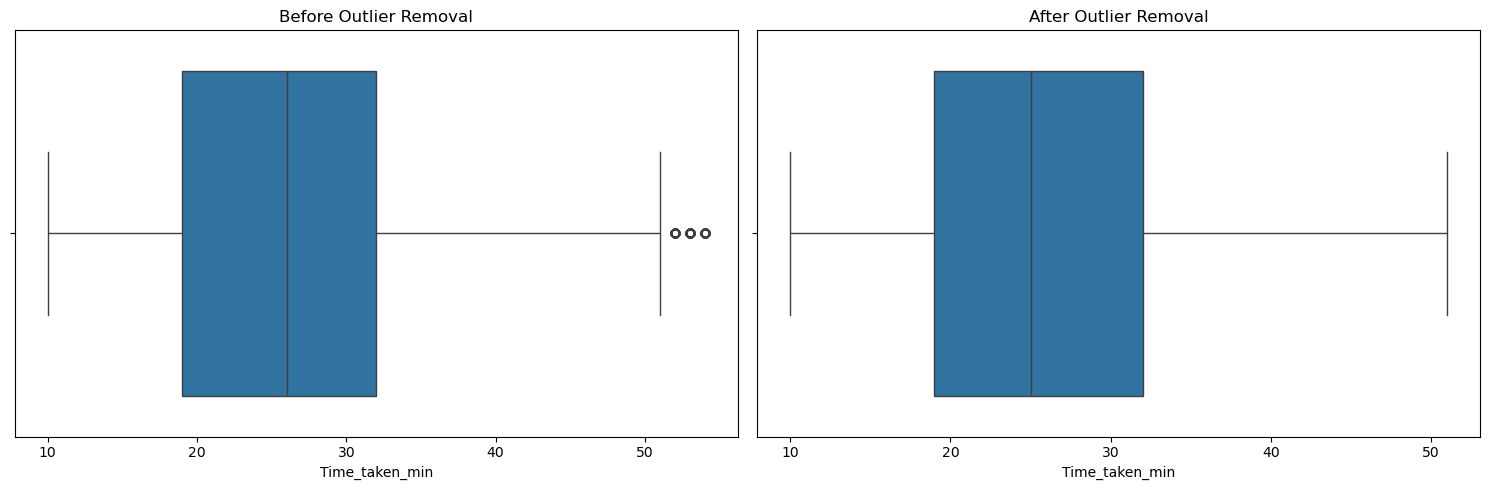

In [12]:
# Plot side by side
plt.figure(figsize=(15, 5))

# BEFORE
plt.subplot(1, 2, 1)
sns.boxplot(x=df_before['Time_taken_min'])
plt.title("Before Outlier Removal")

# AFTER
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Time_taken_min'])
plt.title("After Outlier Removal")

plt.tight_layout()

# SAVE IMAGE
plt.savefig(r"C:\Users\CompFix\Desktop\food-delivery-time-prediction\outputs\charts\outlier_removal_boxplot.png")

# SHOW PLOT
plt.show()

In [13]:
# Save cleaned dataset
df.to_csv(r"C:\Users\CompFix\Desktop\food-delivery-time-prediction\outputs\cleaned_delivery_dataset1.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r"C:\Users\CompFix\Desktop\food-delivery-time-prediction\outputs\cleaned_delivery_dataset1.csv")

In [15]:
print("Final cleaned Preprocessed Columns:")
print(df.columns)
print(f"Final Dataset Shape: {df.shape}")

Final cleaned Preprocessed Columns:
Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Vehicle_condition',
       'multiple_deliveries', 'Time_taken_min', 'Order_day', 'Order_hour',
       'Delivery_time_diff', 'Weatherconditions_conditions Fog',
       'Weatherconditions_conditions Sandstorms',
       'Weatherconditions_conditions Stormy',
       'Weatherconditions_conditions Sunny',
       'Weatherconditions_conditions Windy', 'Road_traffic_density_Jam ',
       'Road_traffic_density_Low ', 'Road_traffic_density_Medium ',
       'Type_of_order_Drinks ', 'Type_of_order_Meal ', 'Type_of_order_Snack ',
       'Type_of_vehicle_motorcycle ', 'Type_of_vehicle_scooter ', 'City_NaN ',
       'City_Semi-Urban ', 'City_Urban ', 'Festival_No ', 'Festival_Yes '],
      dtype='object')
Final Dataset Shape: (43607, 30)


In [18]:
df.columns = df.columns.str.strip()
df_desc = df.copy()

#  Descriptive analysis: 

In [19]:
num_cols = ['Delivery_person_Age', 'Delivery_person_Ratings',
            'multiple_deliveries', 'Time_taken_min',
            'Delivery_time_diff', 'Order_hour']

desc_stats = df_desc[num_cols].describe().T
desc_stats['median']   = df_desc[num_cols].median()
desc_stats['skewness'] = df_desc[num_cols].skew()
desc_stats['kurtosis'] = df_desc[num_cols].kurtosis()
desc_stats['IQR']      = desc_stats['75%'] - desc_stats['25%']

display(desc_stats[['count','mean','median','std','min','25%','50%','75%','max','IQR','skewness','kurtosis']].round(2))

,count,mean,median,std,min,25%,50%,75%,max,IQR,skewness,kurtosis
Delivery_person_Age,43607.0,29.54,30.0,5.75,20.0,25.0,30.0,35.0,39.0,10.0,-0.01,-1.20
Delivery_person_Ratings,43607.0,4.64,4.7,0.31,2.5,4.5,4.7,4.9,5.0,0.4,-1.81,5.26
multiple_deliveries,43607.0,0.74,1.0,0.56,0.0,0.0,1.0,1.0,3.0,1.0,0.23,0.74
Time_taken_min,43607.0,26.14,25.0,9.17,10.0,19.0,25.0,32.0,51.0,13.0,0.42,-0.45
Delivery_time_diff,43607.0,9.77,10.0,4.27,0.0,5.0,10.0,15.0,15.0,10.0,-0.09,-1.23
Order_hour,43607.0,17.41,19.0,4.83,0.0,15.0,19.0,21.0,23.0,6.0,-1.02,0.44


# Data visualization

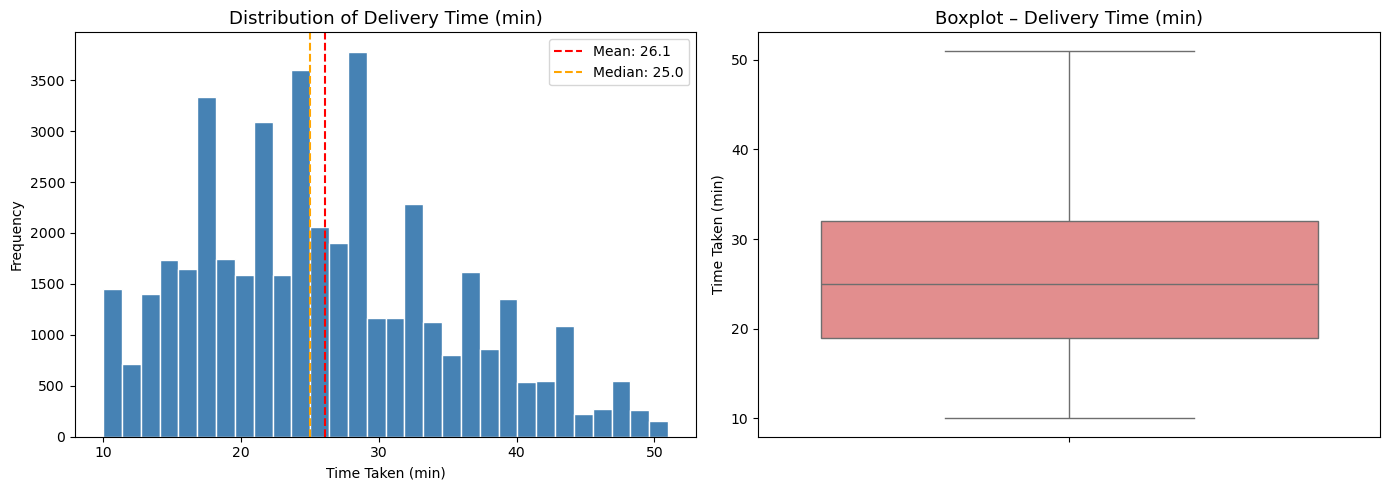

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(
    df_desc['Time_taken_min'].dropna(),
    bins=30,
    color='steelblue',
    edgecolor='white'
)

axes[0].axvline(
    df_desc['Time_taken_min'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean: {df_desc['Time_taken_min'].mean():.1f}"
)

axes[0].axvline(
    df_desc['Time_taken_min'].median(),
    color='orange',
    linestyle='--',
    label=f"Median: {df_desc['Time_taken_min'].median():.1f}"
)

axes[0].set_title('Distribution of Delivery Time (min)', fontsize=13)
axes[0].set_xlabel('Time Taken (min)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Boxplot
sns.boxplot(
    y=df_desc['Time_taken_min'],
    ax=axes[1],
    color='lightcoral'
)

axes[1].set_title('Boxplot – Delivery Time (min)', fontsize=13)
axes[1].set_ylabel('Time Taken (min)')

plt.tight_layout()

# SAVE THE PLOT
plt.savefig(
    r"C:\Users\CompFix\Desktop\food-delivery-time-prediction\outputs\charts\delivery_time_analysis.png",
    dpi=300,
    bbox_inches='tight'
)

# SHOW THE PLOT
plt.show()

The histogram shows that delivery times are approximately normally distributed, centred around 26–27 minutes. The mean and median are very close, indicating minimal skewness after outlier removal. The boxplot confirms a tight interquartile range with no remaining extreme values.

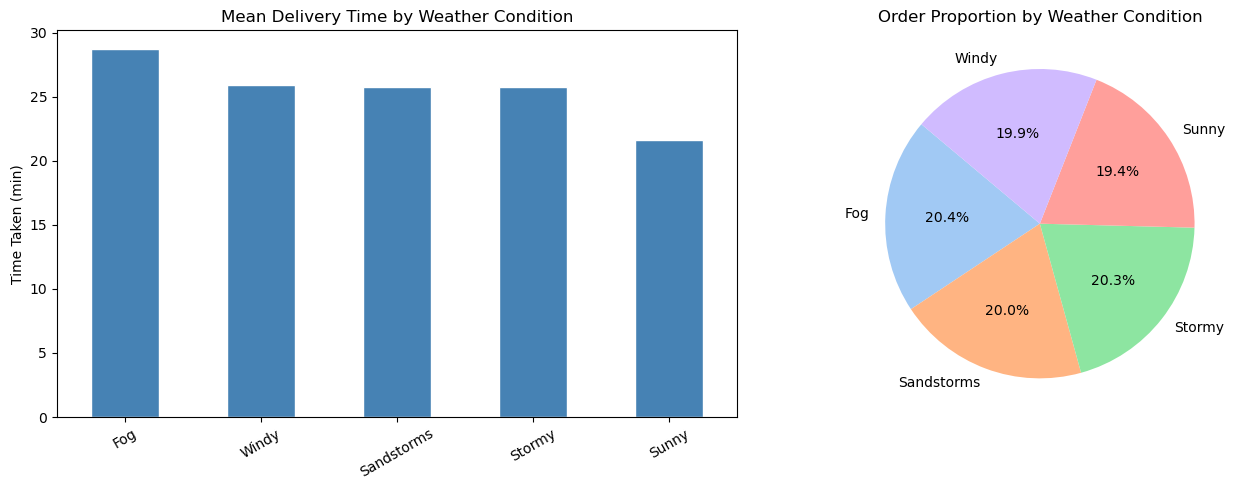

In [24]:
weather_cols = [col for col in df_desc.columns if 'Weatherconditions' in col]

weather_mean = {}
for col in weather_cols:
    weather_mean[col] = df_desc[df_desc[col] == 1]['Time_taken_min'].mean()

weather_mean = pd.Series(weather_mean).sort_values(ascending=False)
weather_mean.index = weather_mean.index.str.replace('Weatherconditions_conditions ', '', regex=False).str.strip()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

weather_mean.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Mean Delivery Time by Weather Condition')
axes[0].set_ylabel('Time Taken (min)')
axes[0].tick_params(axis='x', rotation=30)

weather_count = {col.replace('Weatherconditions_conditions ', '').strip(): df_desc[col].sum()
                 for col in [c for c in df_desc.columns if 'Weatherconditions' in c]}
pd.Series(weather_count).plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                               colors=sns.color_palette('pastel'), startangle=140)
axes[1].set_title('Order Proportion by Weather Condition')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(
    r"C:\Users\CompFix\Desktop\food-delivery-time-prediction\outputs\charts\weather_condition_analysis.png"
)
plt.show()

Stormy and Sandstorm conditions show the highest average delivery times, suggesting adverse weather significantly slows deliveries. Sunny conditions account for the largest proportion of orders, meaning most deliveries occur under favourable weather.

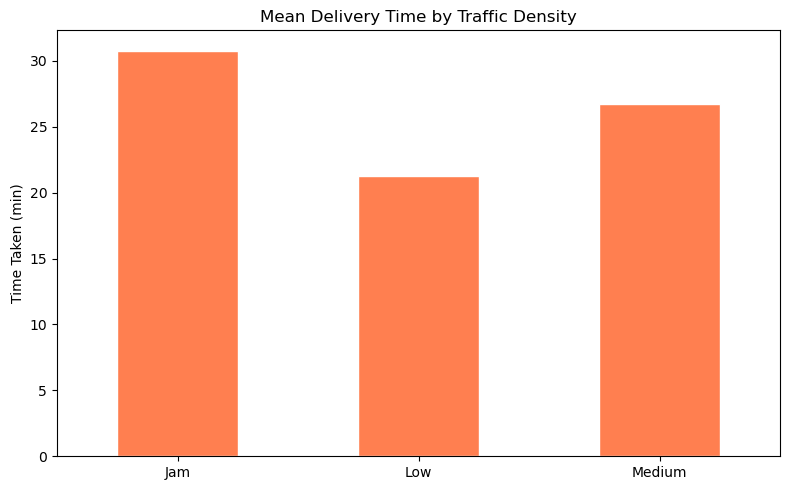

In [25]:
traffic_cols = [col for col in df_desc.columns if 'Road_traffic_density' in col]

traffic_mean = {}
for col in traffic_cols:
    traffic_mean[col] = df_desc[df_desc[col] == 1]['Time_taken_min'].mean()

traffic_mean = pd.Series(traffic_mean)
traffic_mean.index = traffic_mean.index.str.replace('Road_traffic_density_', '', regex=False).str.strip()

plt.figure(figsize=(8, 5))
traffic_mean.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Mean Delivery Time by Traffic Density')
plt.ylabel('Time Taken (min)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    r"C:\Users\CompFix\Desktop\food-delivery-time-prediction\outputs\charts\delivery_analysis.png"
)
plt.show()

Jam traffic conditions produce the longest average delivery time (30.78 min), nearly 10 minutes longer than Low traffic (21.28 min). This confirms traffic density as one of the strongest predictors of delivery delay.

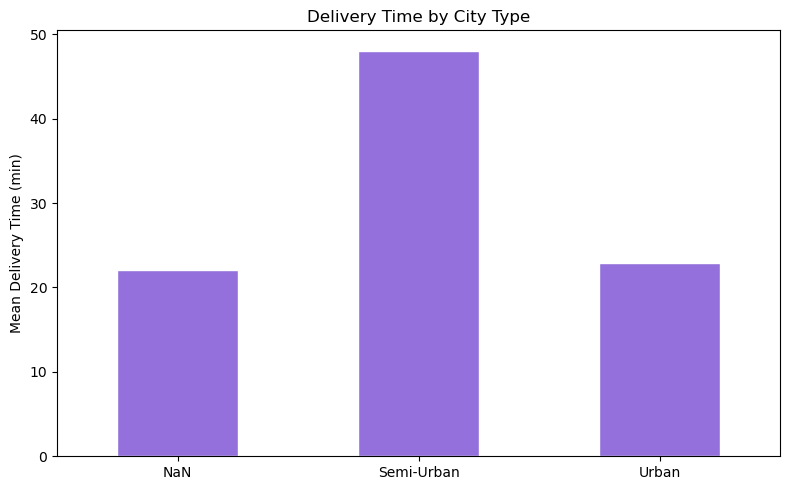

In [26]:
city_cols = [col for col in df_desc.columns if 'City_' in col]

city_mean = {}
for col in city_cols:
    city_mean[col] = df_desc[df_desc[col] == 1]['Time_taken_min'].mean()

city_mean = pd.Series(city_mean)
city_mean.index = city_mean.index.str.replace('City_', '', regex=False).str.strip()

city_mean.plot(kind='bar', title='Delivery Time by City Type',
               color='mediumpurple', edgecolor='white', figsize=(8, 5))
plt.ylabel('Mean Delivery Time (min)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    r"C:\Users\CompFix\Desktop\food-delivery-time-prediction\outputs\charts\Delivery_Time_by_City_Type.png"
)
plt.show()

Urban city deliveries take longer on average compared to Semi-Urban areas, likely due to higher traffic congestion and more complex road networks in dense urban environments.

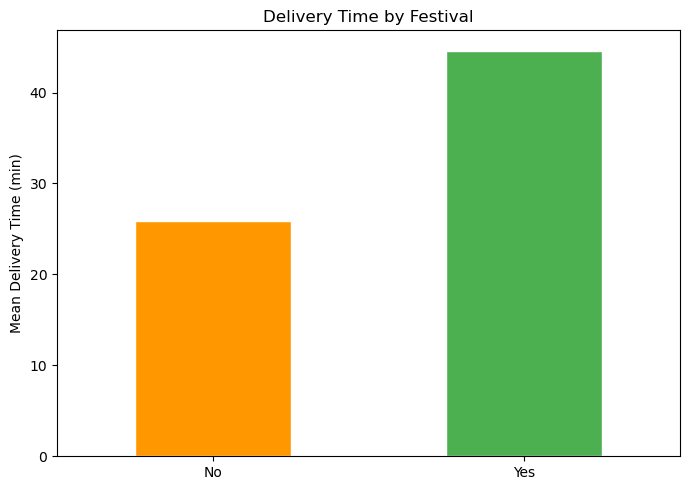

In [27]:
festival_cols = [col for col in df_desc.columns if 'Festival_' in col]

festival_mean = {}
for col in festival_cols:
    festival_mean[col] = df_desc[df_desc[col] == 1]['Time_taken_min'].mean()

festival_mean = pd.Series(festival_mean)
festival_mean.index = festival_mean.index.str.replace('Festival_', '', regex=False).str.strip()

festival_mean.plot(kind='bar', title='Delivery Time by Festival',
                   color=['#FF9800', '#4CAF50'], edgecolor='white', figsize=(7, 5))
plt.ylabel('Mean Delivery Time (min)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    r"C:\Users\CompFix\Desktop\food-delivery-time-prediction\outputs\charts\Delivery_Time_by_Festival.png"
)
plt.show()

Festival deliveries average 44.61 minutes compared to 25.81 minutes on non-festival days — a difference of nearly 19 minutes. This strongly indicates that festive periods create significant delivery delays.

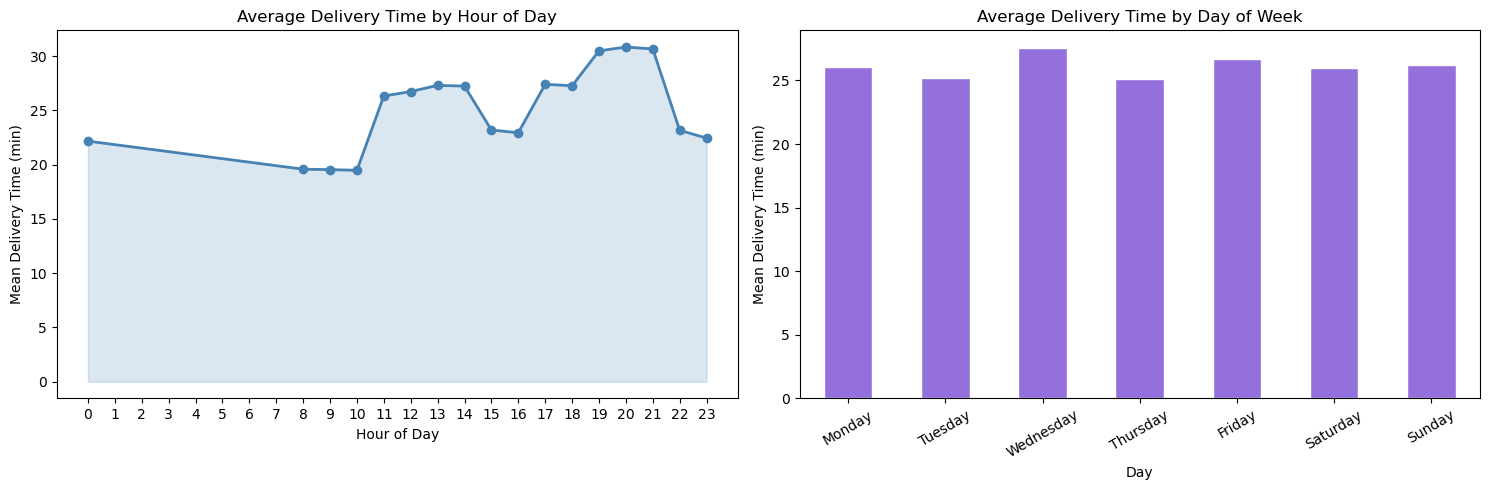

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Orders per hour
hourly = df_desc.groupby('Order_hour')['Time_taken_min'].mean()
axes[0].plot(hourly.index, hourly.values, marker='o', color='steelblue', linewidth=2)
axes[0].fill_between(hourly.index, hourly.values, alpha=0.2, color='steelblue')
axes[0].set_title('Average Delivery Time by Hour of Day', fontsize=12)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Mean Delivery Time (min)')
axes[0].set_xticks(range(0, 24))

# Day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_mean  = df_desc.groupby('Order_day')['Time_taken_min'].mean().reindex(day_order)
day_mean.plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Average Delivery Time by Day of Week', fontsize=12)
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Mean Delivery Time (min)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(
    r"C:\Users\CompFix\Desktop\food-delivery-time-prediction\outputs\charts\Average_Delivery_Time_by_Hour_OR_Week.png"
)
plt.show()

Delivery times peak during evening hours (18:00–22:00), coinciding with dinner demand and road congestion. Across days of the week, delivery times remain relatively consistent, suggesting demand is spread evenly throughout the week.

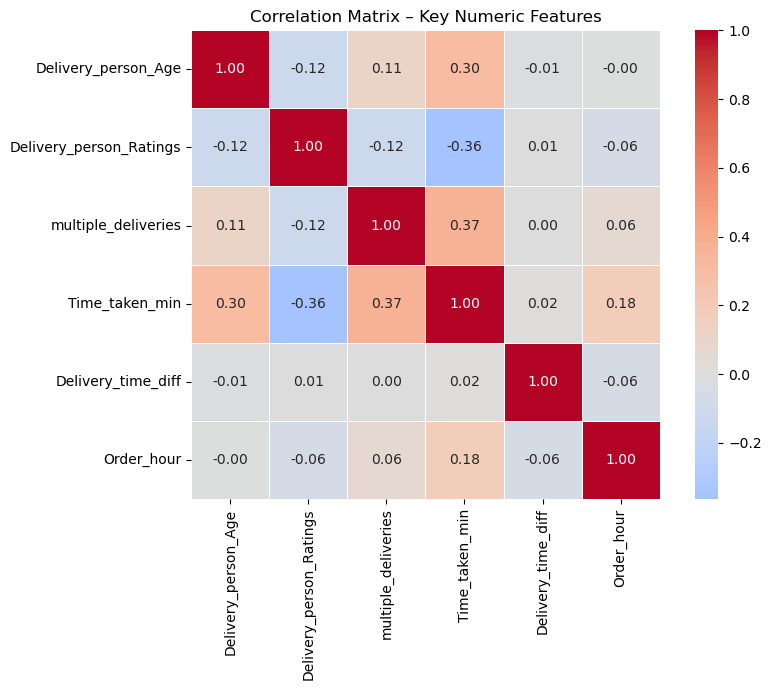

In [32]:
corr_cols = ['Delivery_person_Age', 'Delivery_person_Ratings',
             'multiple_deliveries', 'Time_taken_min',
             'Delivery_time_diff', 'Order_hour']

corr_matrix = df_desc[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Matrix – Key Numeric Features')
plt.tight_layout()
plt.savefig(
    r"C:\Users\CompFix\Desktop\food-delivery-time-prediction\outputs\charts\Correlation_matrics.png"
)
plt.show()

The heatmap reveals a moderate negative correlation between delivery person ratings and delivery time (r = −0.36), meaning higher-rated personnel tend to deliver faster. Multiple deliveries show a weak positive correlation with delivery time, as expected.

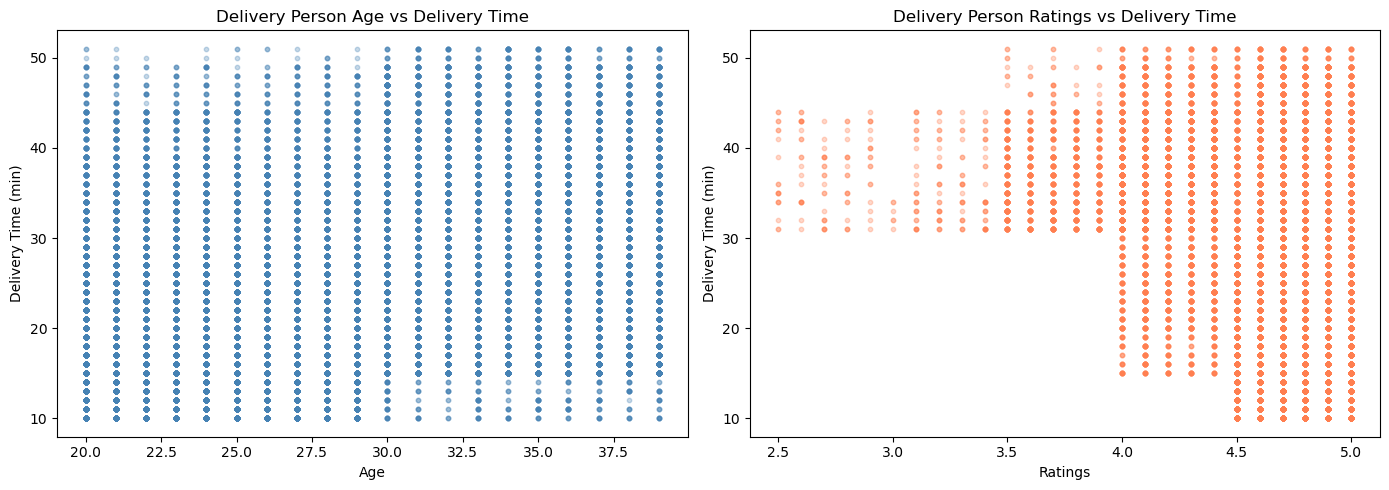

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(df_desc['Delivery_person_Age'], df_desc['Time_taken_min'],
                alpha=0.3, color='steelblue', s=10)
axes[0].set_title('Delivery Person Age vs Delivery Time', fontsize=12)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Delivery Time (min)')

# Ratings vs Delivery Time
axes[1].scatter(df_desc['Delivery_person_Ratings'], df_desc['Time_taken_min'],
                alpha=0.3, color='coral', s=10)
axes[1].set_title('Delivery Person Ratings vs Delivery Time', fontsize=12)
axes[1].set_xlabel('Ratings')
axes[1].set_ylabel('Delivery Time (min)')

plt.tight_layout()
plt.savefig(
    r"C:\Users\CompFix\Desktop\food-delivery-time-prediction\outputs\charts\Age_and_rating.png"
)
plt.show()

No strong linear trend is visible between age and delivery time, suggesting age alone is not a reliable predictor. The ratings scatter plot confirms the negative trend — lower-rated delivery personnel are associated with longer delivery times.

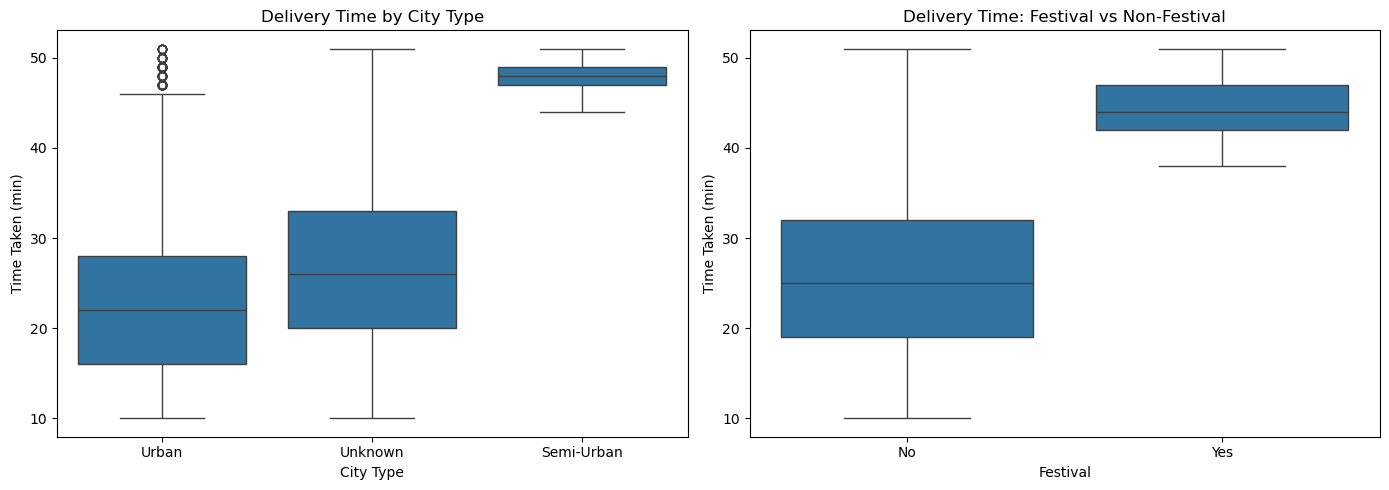

In [36]:
# Recreate City column
df_desc['City_Label'] = np.select(
    [
        df_desc['City_Urban'] == 1,
        df_desc['City_Semi-Urban'] == 1,
        df_desc['City_NaN'] == 1
    ],
    ['Urban', 'Semi-Urban', 'Unknown'],
    default='Unknown'
)

# Recreate Festival column
df_desc['Festival_Label'] = np.where(df_desc['Festival_Yes'] == 1, 'Yes', 'No')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# City plot
sns.boxplot(data=df_desc, x='City_Label', y='Time_taken_min', ax=axes[0])
axes[0].set_title('Delivery Time by City Type')
axes[0].set_xlabel('City Type')
axes[0].set_ylabel('Time Taken (min)')

# Festival plot
sns.boxplot(data=df_desc, x='Festival_Label', y='Time_taken_min', ax=axes[1])
axes[1].set_title('Delivery Time: Festival vs Non-Festival')
axes[1].set_xlabel('Festival')
axes[1].set_ylabel('Time Taken (min)')

plt.tight_layout()
plt.savefig(
    r"C:\Users\CompFix\Desktop\food-delivery-time-prediction\outputs\charts\DeliveryTimeByCityType_and_FastivelVSnonFastival.png"
)
plt.show()

The boxplots confirm that Urban deliveries have greater variability in delivery time compared to Semi-Urban. Festival boxplots show a clearly higher median and wider spread, reinforcing that festivals are a significant disrupting factor.

# statistical analyses - Hypothesis Testing

In [37]:
import numpy as np

# Traffic label
df_desc['Traffic_Label'] = np.select(
    [
        df_desc['Road_traffic_density_Jam'] == 1,
        df_desc['Road_traffic_density_Low'] == 1,
        df_desc['Road_traffic_density_Medium'] == 1
    ],
    ['Jam', 'Low', 'Medium'],
    default='High'
)

# Festival label
df_desc['Festival_Label'] = np.where(df_desc['Festival_Yes'] == 1, 'Yes', 'No')

print("Traffic label distribution:")
print(df_desc['Traffic_Label'].value_counts())

Traffic label distribution:
Traffic_Label
Low       15062
Jam       13568
Medium    10678
High       4299
Name: count, dtype: int64


### ANOVA
One-Way ANOVA was selected because we are comparing the mean delivery time across more than two independent groups (Low, Medium, High, Jam traffic). ANOVA is the appropriate test in this case as it determines whether at least one group mean is statistically different from the others, without inflating the Type I error rate that would occur from running multiple t-tests.

In [38]:
from scipy.stats import f_oneway

groups = df_desc.groupby('Traffic_Label')['Time_taken_min'].apply(list)

f_stat, p_val_anova = f_oneway(*groups)

print("=== ANOVA: Traffic vs Delivery Time ===")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val_anova:.6f}")

if p_val_anova < 0.05:
    print("Reject H₀ → Traffic density significantly affects delivery time (p < 0.05)")
else:
    print("Fail to reject H₀")

print("\nMean delivery time per traffic level:")
print(df_desc.groupby('Traffic_Label')['Time_taken_min'].mean().round(2))

=== ANOVA: Traffic vs Delivery Time ===
F-statistic: 3160.3036
P-value: 0.000000
Reject H₀ → Traffic density significantly affects delivery time (p < 0.05)

Mean delivery time per traffic level:
Traffic_Label
High      27.07
Jam       30.78
Low       21.28
Medium    26.72
Name: Time_taken_min, dtype: float64


### t-test
An independent samples t-test was selected because we are comparing the mean delivery time between exactly two independent groups — festival and non-festival days. This test is suitable here as the two groups are mutually exclusive and we are testing whether the difference in their means is statistically significant.

In [39]:
from scipy.stats import ttest_ind

festival_yes = df_desc[df_desc['Festival_Label'] == 'Yes']['Time_taken_min']
festival_no  = df_desc[df_desc['Festival_Label'] == 'No']['Time_taken_min']

t_stat, p_val_ttest = ttest_ind(festival_yes, festival_no)

print("\n=== T-test: Festival vs Delivery Time ===")
print(f"Festival mean     : {festival_yes.mean():.2f} min  (n={len(festival_yes)})")
print(f"Non-Festival mean : {festival_no.mean():.2f} min  (n={len(festival_no)})")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val_ttest:.6f}")

if p_val_ttest < 0.05:
    print("Reject H₀ → Festival significantly affects delivery time (p < 0.05)")
else:
    print("Fail to reject H₀")


=== T-test: Festival vs Delivery Time ===
Festival mean     : 44.61 min  (n=768)
Non-Festival mean : 25.81 min  (n=42839)
T-statistic: 58.4741
P-value: 0.000000
Reject H₀ → Festival significantly affects delivery time (p < 0.05)


### Pearson Correlation
Pearson Correlation was selected because we are examining the linear relationship between two continuous numeric variables — delivery person ratings and delivery time. Both variables are numeric and continuous, making Pearson's r the appropriate measure of the strength and direction of their association.

In [40]:
from scipy.stats import pearsonr

corr_data = df_desc[['Delivery_person_Ratings', 'Time_taken_min']].dropna()

r, p_corr = pearsonr(corr_data['Delivery_person_Ratings'], corr_data['Time_taken_min'])

print("\n=== Correlation: Ratings vs Delivery Time ===")
print(f"Pearson r : {r:.4f}")
print(f"P-value   : {p_corr:.6f}")

if p_corr < 0.05:
    print(f"Result: Reject H₀ → Significant {'negative' if r < 0 else 'positive'} correlation exists (p < 0.05)")
else:
    print("Result: Fail to reject H₀")


=== Correlation: Ratings vs Delivery Time ===
Pearson r : -0.3623
P-value   : 0.000000
Result: Reject H₀ → Significant negative correlation exists (p < 0.05)


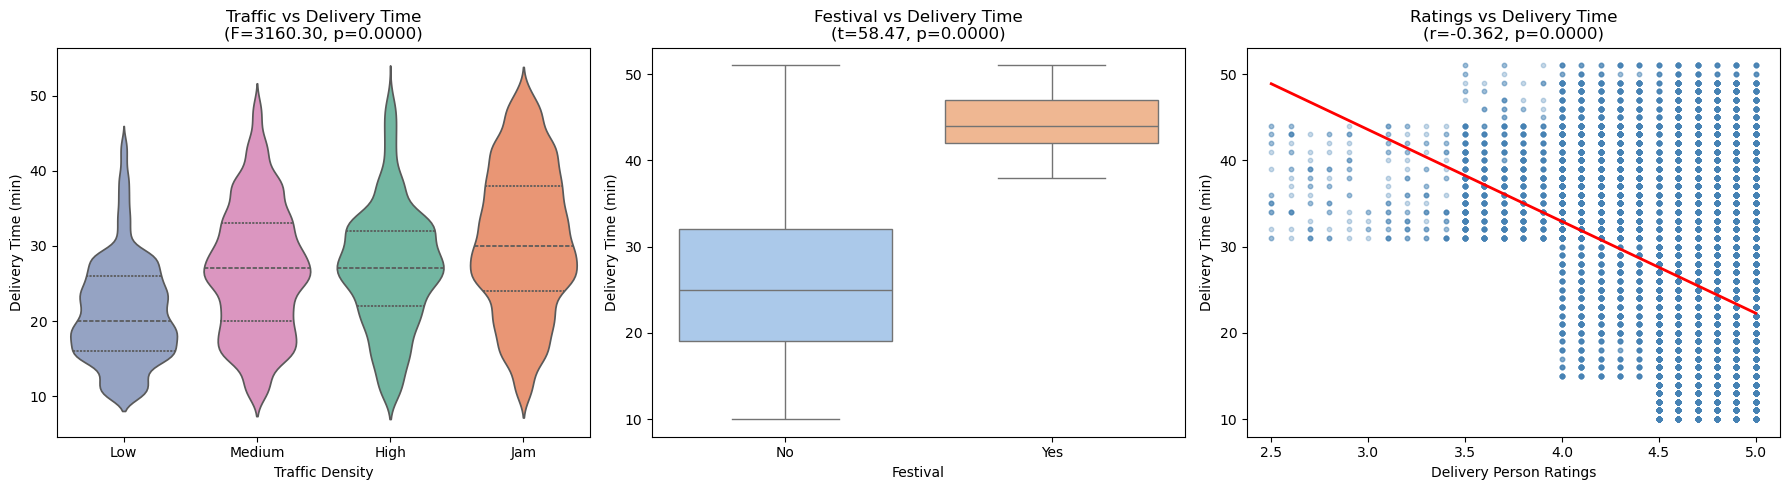

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ANOVA – violin plot
traffic_order = ['Low', 'Medium', 'High', 'Jam']
sns.violinplot(
    data=df_desc,
    x='Traffic_Label',
    y='Time_taken_min',
    order=traffic_order,
    hue='Traffic_Label',  
    palette='Set2',
    inner='quartile',
    ax=axes[0],
    legend=False          
)

axes[0].set_title(f'Traffic vs Delivery Time\n(F={f_stat:.2f}, p={p_val_anova:.4f})')
axes[0].set_xlabel('Traffic Density')
axes[0].set_ylabel('Delivery Time (min)')


# T-test – boxplot
sns.boxplot(
    data=df_desc,
    x='Festival_Label',
    y='Time_taken_min',
    hue='Festival_Label',  
    palette='pastel',
    ax=axes[1],
    legend=False           
)

axes[1].set_title(f'Festival vs Delivery Time\n(t={t_stat:.2f}, p={p_val_ttest:.4f})')
axes[1].set_xlabel('Festival')
axes[1].set_ylabel('Delivery Time (min)')


# Pearson – scatter
axes[2].scatter(
    corr_data['Delivery_person_Ratings'],
    corr_data['Time_taken_min'],
    alpha=0.3,
    s=10,
    color='steelblue'
)

m, b = np.polyfit(
    corr_data['Delivery_person_Ratings'],
    corr_data['Time_taken_min'], 1
)

x_line = np.linspace(
    corr_data['Delivery_person_Ratings'].min(),
    corr_data['Delivery_person_Ratings'].max(), 100
)

axes[2].plot(x_line, m * x_line + b, color='red', linewidth=2)

axes[2].set_title(f'Ratings vs Delivery Time\n(r={r:.3f}, p={p_corr:.4f})')
axes[2].set_xlabel('Delivery Person Ratings')
axes[2].set_ylabel('Delivery Time (min)')

plt.tight_layout()
plt.savefig(
    r"C:\Users\CompFix\Desktop\food-delivery-time-prediction\outputs\charts\test_results.png"
)
plt.show()